In [1]:
# Imports
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
SEED = 418763

# Read dataset
df = pd.read_csv("pokemon.csv")

---
## Task 1 — Exploratory Data Analysis

## 1.1 Display the shape of the dataset and the first few rows.

In [3]:
df.head()

,ID,Name,Type_1,Type_2,Total,HP,Attack,Defense,Sp_Atk,Sp_Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,4,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [4]:
df.shape

(800, 13)

## 1.2 Check for missing values across all columns and report your findings.

In [5]:
df.isna().sum()

ID              0
Name            0
Type_1          0
Type_2        386
Total           0
HP              0
Attack          0
Defense         0
Sp_Atk          0
Sp_Def          0
Speed           0
Generation      0
Legendary       0
dtype: int64

There are 386 missing valus in the column Type_2, which represents "elemental type(s) of the Pokemon". These are nan values, as in, they do not exist in the dataset.

## 1.3 Plot the class distribution of the Legendary column. Comment on what you observe.

<Axes: xlabel='Legendary'>

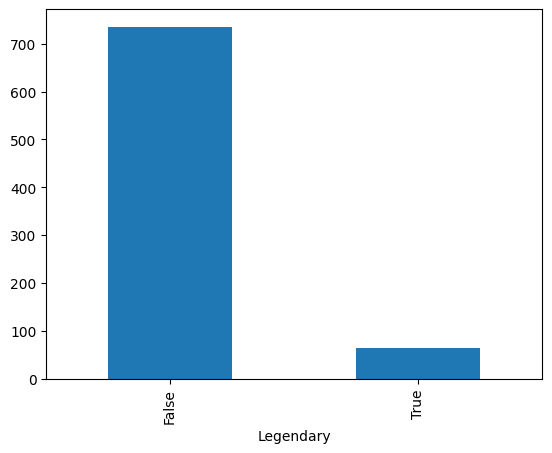

In [6]:
df["Legendary"].value_counts().plot(kind="bar")

The bar chart tells us that there are around 700 False and around 60 True values. Which makes judging accuracy only an inaccurate assessment, since a model that predicts False for all predictions will be correct most times.

## 1.4 Plot distributions or boxplots comparing the stats (HP, Attack, Defense, etc.) between legendary and non-legendary Pokemon. Identify features that appear most useful for separating the two classes.

<Axes: xlabel='Legendary'>

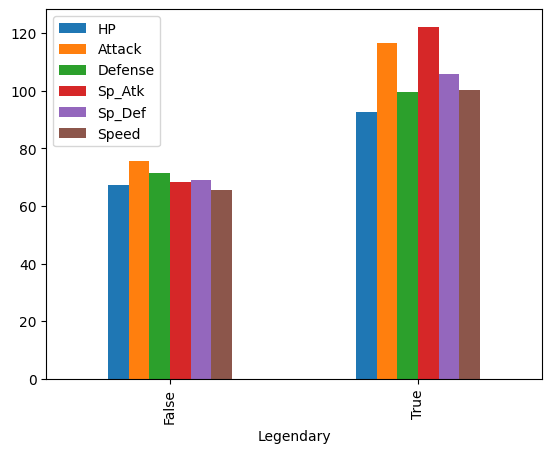

In [7]:
df.groupby("Legendary")[["HP", "Attack", "Defense", "Sp_Atk", "Sp_Def", "Speed"]].mean().plot(kind="bar")

Attack and Sp_attack seem to be more useful for identifying whether a pokemon is legendary or not since legendary pokemons have it a very high number.

**1.5 EDA Summary** *(3–5 sentences — what does the EDA tell you about class balance, data quality, and discriminative features?)*

- 

---
## Task 2 — Data Preparation

## 2.1 Examine the columns in the dataset. Not all columns are suitable for use as features - identify and drop any that are not appropriate, and briefly comment in a markdown cell explaining your choices.

In [8]:
# Drop columns that aren't appropriate for modeling
df = df.drop(columns=["ID","Name","Type_1","Type_2", "Generation"])
df.head()

,Total,HP,Attack,Defense,Sp_Atk,Sp_Def,Speed,Legendary
0,318,45,49,49,65,65,45,False
1,405,60,62,63,80,80,60,False
2,525,80,82,83,100,100,80,False
3,625,80,100,123,122,120,80,False
4,309,39,52,43,60,50,65,False


**2.1 Column Dropping Justification** *(briefly explain which columns you dropped and why)*

- I dropped ID and Name since these identifiers and bear no role in making a pokemon legendary.
- I dropped Type_1, Type_2, and Generation since these aren't directly related to a pokemon's skills so they shouldn't matter as to whether they're legendary or not.

## 2.2 Split the data into training, validation, and test sets using a 60/20/20 split. Use stratification on the target column and your student ID as the random seed.

In [9]:
# Split the data into training, validation, and test sets using a 60/20/20 split
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["Legendary"])
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=SEED, stratify=train_val_df["Legendary"])

---
## Task 3 — Model Training with Cross-Validation

### Model A - LR

**Model A — Classifier choice and justification** *(1–2 sentences)*

Logistic Regression is a simple, interpretable baseline well-suited for binary classification. It trains quickly and provides probability estimates, making it a good starting point before trying more complex models.

In [10]:
# Model A — Logistic Regression
# 1. Classifier type: Logistic Regression — see justification in markdown cell above.

# --- Features & Labels ---
X_train = train_df.drop(columns=["Legendary"])
y_train = train_df["Legendary"]

X_val = val_df.drop(columns=["Legendary"])
y_val = val_df["Legendary"]

# 2. Define a parameter grid and run a cross-validated hyperparameter search on the training set.
param_grid_a = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"]
}

grid_a = GridSearchCV(LogisticRegression(random_state=SEED, max_iter=1000),
                      param_grid_a, cv=5, scoring="f1")
grid_a.fit(X_train, y_train)

# 3. Report the best parameters found and the mean CV score.
print("Model A — Logistic Regression")
print(f"Best Params: {grid_a.best_params_}")
print(f"Best Mean CV F1: {grid_a.best_score_:.4f}")

# --- Best Model Evaluation on Validation Set ---
model_a = grid_a.best_estimator_
y_val_pred_a = model_a.predict(X_val)

print("\n--- Validation Set Performance ---")
print(classification_report(y_val, y_val_pred_a))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_a))


Model A — Logistic Regression
Best Params: {'C': 0.01, 'solver': 'lbfgs'}
Best Mean CV F1: 0.4598

--- Validation Set Performance ---
              precision    recall  f1-score   support

       False       0.95      0.99      0.97       147
        True       0.75      0.46      0.57        13

    accuracy                           0.94       160
   macro avg       0.85      0.72      0.77       160
weighted avg       0.94      0.94      0.94       160

Confusion Matrix:
[[145   2]
 [  7   6]]


### Model B - k-Nearest Neighbours

**Model B — Classifier choice and justification** *(1–2 sentences)*

K-Nearest Neighbours classifies based on the majority class among the closest training examples, making it non-parametric and flexible. It can capture local patterns in the feature space without assuming any underlying distribution.

In [11]:
# Model B — k-Nearest Neighbours
# 1. Classifier type: k-Nearest Neighbours — see justification in markdown cell above.

# 2. Define a parameter grid and run a cross-validated hyperparameter search on the training set.
param_grid_b = {
    "n_neighbors": [3, 5, 7, 11, 15],
    "weights": ["uniform", "distance"]
}

grid_b = GridSearchCV(KNeighborsClassifier(),
                      param_grid_b, cv=5, scoring="f1")
grid_b.fit(X_train, y_train)

# 3. Report the best parameters found and the mean CV score.
print("Model B — k-Nearest Neighbours")
print(f"Best Params: {grid_b.best_params_}")
print(f"Best Mean CV F1: {grid_b.best_score_:.4f}")

# --- Best Model Evaluation on Validation Set ---
model_b = grid_b.best_estimator_
y_val_pred_b = model_b.predict(X_val)

print("\n--- Validation Set Performance ---")
print(classification_report(y_val, y_val_pred_b))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_b))


Model B — k-Nearest Neighbours
Best Params: {'n_neighbors': 7, 'weights': 'distance'}
Best Mean CV F1: 0.7230

--- Validation Set Performance ---
              precision    recall  f1-score   support

       False       0.97      0.99      0.98       147
        True       0.89      0.62      0.73        13

    accuracy                           0.96       160
   macro avg       0.93      0.80      0.85       160
weighted avg       0.96      0.96      0.96       160

Confusion Matrix:
[[146   1]
 [  5   8]]


### Model C - Random Forest

**Model C — Classifier choice and justification** *(1–2 sentences)*

Random Forest is an ensemble of decision trees that reduces overfitting through bagging, making it robust and well-suited for imbalanced datasets. It also provides feature importances, which adds interpretability on top of strong predictive performance.

In [12]:
# Model C — Random Forest
# 1. Classifier type: Random Forest — see justification in markdown cell above.
from sklearn.ensemble import RandomForestClassifier

# 2. Define a parameter grid and run a cross-validated hyperparameter search on the training set.
param_grid_c = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20]
}

grid_c = GridSearchCV(RandomForestClassifier(random_state=SEED),
                      param_grid_c, cv=5, scoring="f1")
grid_c.fit(X_train, y_train)

# 3. Report the best parameters found and the mean CV score.
print("Model C — Random Forest")
print(f"Best Params: {grid_c.best_params_}")
print(f"Best Mean CV F1: {grid_c.best_score_:.4f}")

# --- Best Model Evaluation on Validation Set ---
model_c = grid_c.best_estimator_
y_val_pred_c = model_c.predict(X_val)

print("\n--- Validation Set Performance ---")
print(classification_report(y_val, y_val_pred_c))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_c))


Model C — Random Forest
Best Params: {'max_depth': 5, 'n_estimators': 50}
Best Mean CV F1: 0.6618

--- Validation Set Performance ---
              precision    recall  f1-score   support

       False       0.97      0.99      0.98       147
        True       0.89      0.62      0.73        13

    accuracy                           0.96       160
   macro avg       0.93      0.80      0.85       160
weighted avg       0.96      0.96      0.96       160

Confusion Matrix:
[[146   1]
 [  5   8]]


---
## Task 4 — Model Comparison on Validation Set

In [13]:
# 4.1 & 4.2 Evaluate all three best models on validation set
# Report Accuracy and F1 score for each
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": model_a,
    "k-Nearest Neighbours": model_b,
    "Random Forest": model_c
}

for name, model in models.items():
    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    print(f"{name} — Validation Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

Logistic Regression — Validation Accuracy: 0.9437, F1 Score: 0.5714
k-Nearest Neighbours — Validation Accuracy: 0.9625, F1 Score: 0.7273
Random Forest — Validation Accuracy: 0.9625, F1 Score: 0.7273


**4.3 Comparison Discussion** *(3–5 sentences — which model performs best? Given the class imbalance, which metric is more informative — accuracy or F1 — and why?)*

- KNN and Random Forest both tie for best performance with 96.25% accuracy and an F1 score of 0.7273, while Logistic Regression lags behind at 94.37% accuracy and F1 of 0.5714.
- Given the strong class imbalance (~700 non-legendary vs ~65 legendary), accuracy is a misleading metric — a model that always predicts "Not Legendary" would still exceed 90% accuracy.
- F1 score is far more informative here as it balances precision and recall on the minority class, penalising models that simply ignore it.
- On this metric, Logistic Regression falls noticeably behind, while KNN and Random Forest both handle the minority class considerably better.

---
## Task 5 — Final Evaluation on Test Set

**5.1 Model Selection** *(2–3 sentences — which model did you choose and why?)*

I selected Random Forest as the final model. Although it tied with KNN on both accuracy (96.25%) and F1 (0.7273), Random Forest is generally more robust to noise and less sensitive to feature scaling, making it a safer choice for deployment. It also provides feature importances, adding interpretability that KNN lacks.

In [14]:
# 5.2 Retrain chosen model (Random Forest) on train + validation set using the best hyperparameters found in Task 3.
X_train_val = train_val_df.drop(columns=["Legendary"])
y_train_val = train_val_df["Legendary"]

final_model = RandomForestClassifier(**grid_c.best_params_, random_state=SEED)
final_model.fit(X_train_val, y_train_val)
print(f"Final model retrained with params: {grid_c.best_params_}")

Final model retrained with params: {'max_depth': 5, 'n_estimators': 50}


In [15]:
# 5.3 Evaluate the final model on the test set — print the full classification report.
X_test = test_df.drop(columns=["Legendary"])
y_test = test_df["Legendary"]

y_test_pred = final_model.predict(X_test)

print("Final Model — Random Forest — Test Set Performance")
print(classification_report(y_test, y_test_pred, target_names=["Not Legendary", "Legendary"]))

Final Model — Random Forest — Test Set Performance
               precision    recall  f1-score   support

Not Legendary       0.97      0.99      0.98       147
    Legendary       0.80      0.62      0.70        13

     accuracy                           0.96       160
    macro avg       0.88      0.80      0.84       160
 weighted avg       0.95      0.96      0.95       160



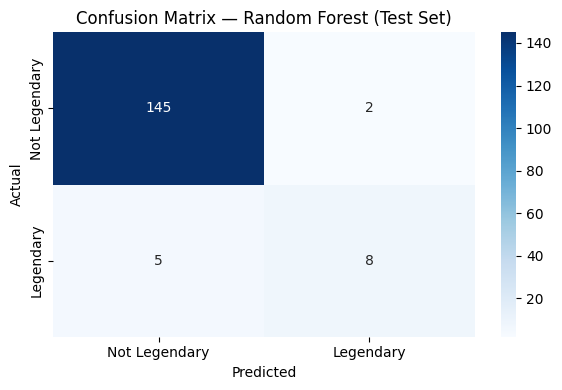

In [16]:
# 5.4 Plot a confusion matrix heatmap for the test set predictions.
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Legendary", "Legendary"],
            yticklabels=["Not Legendary", "Legendary"])
plt.title("Confusion Matrix — Random Forest (Test Set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

**5.5 Final Interpretation** *(3–5 sentences — does the model perform equally on both classes? What does this reveal about class imbalance? Is it deployment-ready?)*

- The model does not perform equally on both classes: "Not Legendary" achieves near-perfect precision (0.97) and recall (0.99), while "Legendary" scores only 0.80 precision and 0.62 recall, with an F1 of 0.70.
- The low recall on Legendary (0.62) means the model misses roughly 38% of actual legendary Pokémon — predicting them as non-legendary — which is a direct consequence of the class imbalance (~147 vs 13 in the test set alone).
- Overall accuracy of 96% is misleadingly high; the weighted F1 of 0.95 is inflated by the dominant majority class, while the macro F1 of 0.84 better reflects the disparity between the two classes.
- The model is not fully deployment-ready for a use case where identifying Legendary Pokémon is critical; techniques such as class weighting (`class_weight='balanced'`), oversampling (SMOTE), or lowering the classification threshold could improve minority class recall.